# EDA Churn Prediction

In [2]:
!pip install -q pandas matplotlib seaborn numpy plotly scikit-learn missingno


[notice] A new release of pip is available: 23.2.1 -> 25.3
[notice] To update, run: pip install --upgrade pip


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Se você quiser usar seaborn (recomendado para os gráficos),
# instale antes com: pip install seaborn
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction import DictVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix

RANDOM_STATE = 42
DATA_PATH = "data/WA_Fn-UseC_-Telco-Customer-Churn.csv"

pd.set_option("display.max_columns", 50)
sns.set(style="whitegrid")

In [5]:
df = pd.read_csv(DATA_PATH)
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [6]:
print(df.shape)
df.info()

(7043, 21)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null

In [7]:
# Normalizar nomes das colunas
df.columns = df.columns.str.strip().str.replace(' ', '_')

# Converter TotalCharges para numérico
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Ver nulos após conversão
df.isnull().sum()


customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

In [8]:
# Remover linhas com TotalCharges nulo
df = df.dropna(subset=['TotalCharges']).reset_index(drop=True)

# Converter Churn para 0/1
df['Churn'] = (df['Churn'].str.strip() == 'Yes').astype(int)

# Distribuição do target
df['Churn'].value_counts(), df['Churn'].value_counts(normalize=True)


(Churn
 0    5163
 1    1869
 Name: count, dtype: int64,
 Churn
 0    0.734215
 1    0.265785
 Name: proportion, dtype: float64)

In [9]:
df_full_train, df_test = train_test_split(
    df,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=df['Churn']
)

df_train, df_val = train_test_split(
    df_full_train,
    test_size=0.25,  # 0.25 de 0.8 = 0.2
    random_state=RANDOM_STATE,
    stratify=df_full_train['Churn']
)

df_train = df_train.reset_index(drop=True)
df_val = df_val.reset_index(drop=True)
df_test = df_test.reset_index(drop=True)

len(df_train), len(df_val), len(df_test)


(4218, 1407, 1407)

In [10]:
y_train = df_train['Churn'].values
y_val = df_val['Churn'].values
y_test = df_test['Churn'].values

y_train.mean(), y_val.mean(), y_test.mean()


(np.float64(0.26576576576576577),
 np.float64(0.2658137882018479),
 np.float64(0.2658137882018479))

Churn
0    5163
1    1869
Name: count, dtype: int64
Churn
0    0.734215
1    0.265785
Name: proportion, dtype: float64


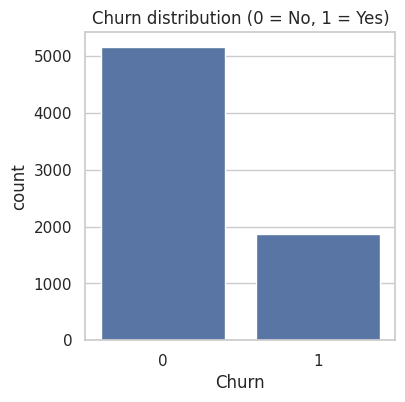

In [11]:
# Contagens
print(df['Churn'].value_counts())
print(df['Churn'].value_counts(normalize=True))

# Gráfico
plt.figure(figsize=(4, 4))
sns.countplot(x='Churn', data=df)
plt.title('Churn distribution (0 = No, 1 = Yes)')
plt.show()


In [12]:
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']
df[num_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
tenure,7032.0,32.421786,24.545260,1.00,9.0000,29.000,55.0000,72.00
MonthlyCharges,7032.0,64.798208,30.085974,18.25,35.5875,70.350,89.8625,118.75
TotalCharges,7032.0,2283.300441,2266.771362,18.80,401.4500,1397.475,3794.7375,8684.80


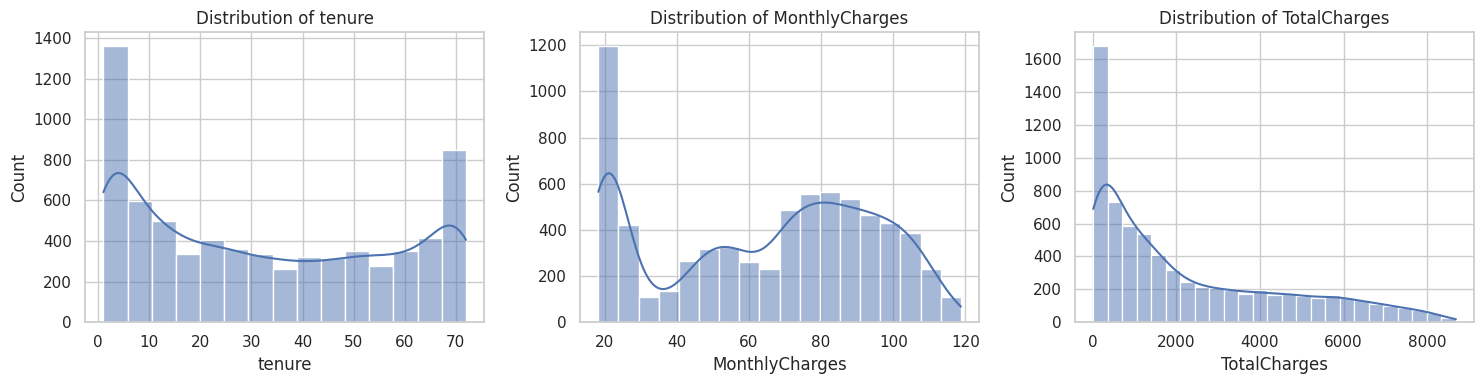

In [13]:
# Histogramas
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for col, ax in zip(num_cols, axes):
    sns.histplot(df[col], kde=True, ax=ax)
    ax.set_title(f'Distribution of {col}')

plt.tight_layout()
plt.show()


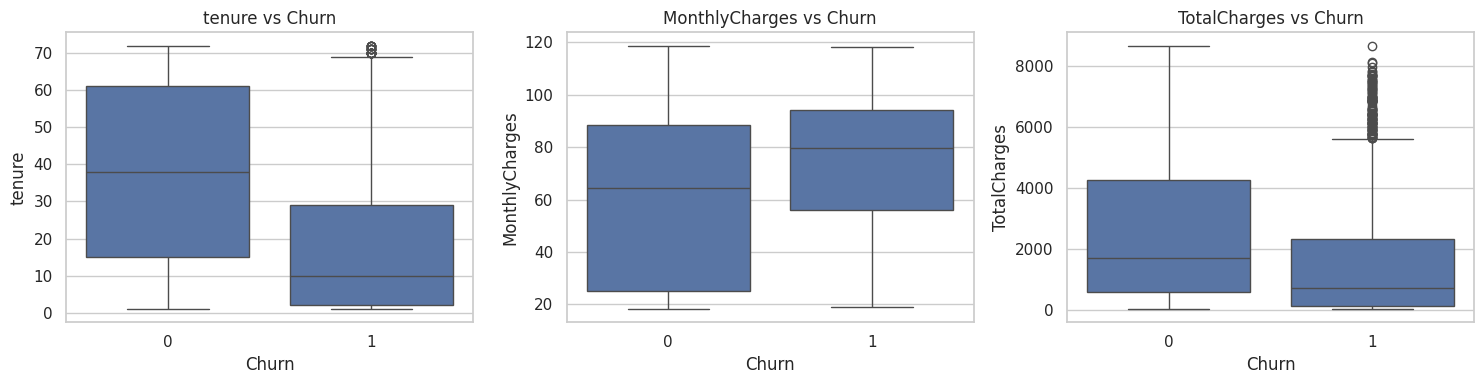

In [14]:
# Boxplots por churn
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for col, ax in zip(num_cols, axes):
    sns.boxplot(x='Churn', y=col, data=df, ax=ax)
    ax.set_title(f'{col} vs Churn')

plt.tight_layout()
plt.show()


In [15]:
cat_cols = [
    'gender', 'SeniorCitizen', 'Partner', 'Dependents',
    'PhoneService', 'MultipleLines', 'InternetService',
    'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
    'TechSupport', 'StreamingTV', 'StreamingMovies',
    'Contract', 'PaperlessBilling', 'PaymentMethod'
]

def churn_rate_by(column):
    return df.groupby(column)['Churn'].mean().sort_values(ascending=False)

for col in ['gender', 'SeniorCitizen', 'Partner', 'Dependents']:
    print(f"\nChurn rate by {col}:")
    print(churn_rate_by(col))



Churn rate by gender:
gender
Female    0.269595
Male      0.262046
Name: Churn, dtype: float64

Churn rate by SeniorCitizen:
SeniorCitizen
1    0.416813
0    0.236503
Name: Churn, dtype: float64

Churn rate by Partner:
Partner
No     0.329761
Yes    0.197171
Name: Churn, dtype: float64

Churn rate by Dependents:
Dependents
No     0.312791
Yes    0.155312
Name: Churn, dtype: float64


In [16]:
for col in ['Contract', 'InternetService', 'PaymentMethod', 'PaperlessBilling']:
    print(f"\nChurn rate by {col}:")
    print(churn_rate_by(col))



Churn rate by Contract:
Contract
Month-to-month    0.427097
One year          0.112772
Two year          0.028487
Name: Churn, dtype: float64

Churn rate by InternetService:
InternetService
Fiber optic    0.418928
DSL            0.189983
No             0.074342
Name: Churn, dtype: float64

Churn rate by PaymentMethod:
PaymentMethod
Electronic check             0.452854
Mailed check                 0.192020
Bank transfer (automatic)    0.167315
Credit card (automatic)      0.152531
Name: Churn, dtype: float64

Churn rate by PaperlessBilling:
PaperlessBilling
Yes    0.335893
No     0.163757
Name: Churn, dtype: float64


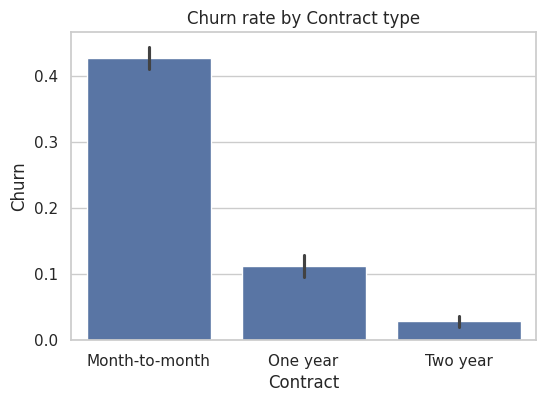

In [17]:
plt.figure(figsize=(6, 4))
sns.barplot(x='Contract', y='Churn', data=df, order=['Month-to-month', 'One year', 'Two year'])
plt.title('Churn rate by Contract type')
plt.show()


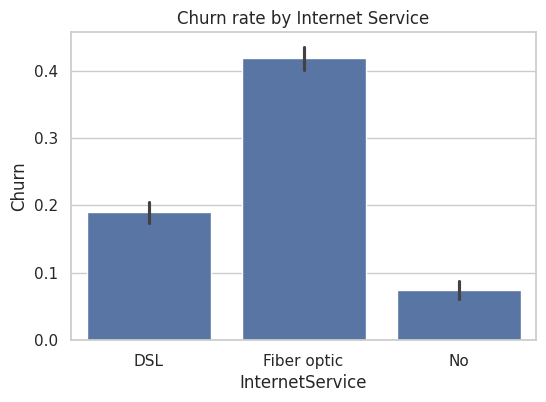

In [18]:
plt.figure(figsize=(6, 4))
sns.barplot(x='InternetService', y='Churn', data=df)
plt.title('Churn rate by Internet Service')
plt.show()


In [19]:
corr = df[num_cols + ['Churn']].corr()
corr


,tenure,MonthlyCharges,TotalCharges,Churn
tenure,1.000000,0.246862,0.825880,-0.354049
MonthlyCharges,0.246862,1.000000,0.651065,0.192858
TotalCharges,0.825880,0.651065,1.000000,-0.199484
Churn,-0.354049,0.192858,-0.199484,1.000000


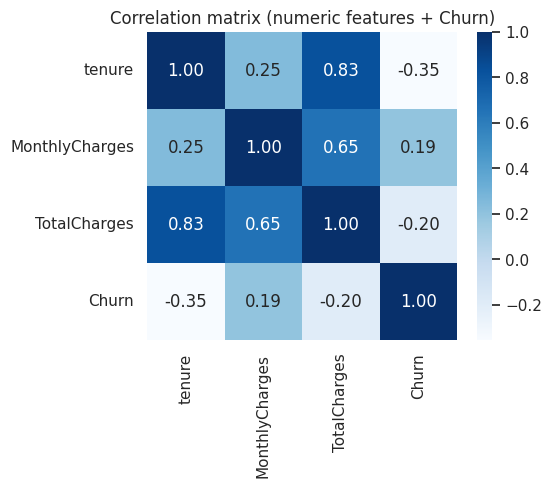

In [20]:
plt.figure(figsize=(5, 4))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='Blues')
plt.title('Correlation matrix (numeric features + Churn)')
plt.show()


In [21]:
def prepare_dicts(df_):
    cols_to_drop = [c for c in ['customerID', 'Churn'] if c in df_.columns]
    df_prep = df_.drop(columns=cols_to_drop, errors='ignore')
    return df_prep.to_dict(orient='records')

train_dicts = prepare_dicts(df_train)
val_dicts = prepare_dicts(df_val)
test_dicts = prepare_dicts(df_test)

dv = DictVectorizer(sparse=True)
X_train = dv.fit_transform(train_dicts)
X_val = dv.transform(val_dicts)
X_test = dv.transform(test_dicts)

X_train.shape, X_val.shape, X_test.shape


((4218, 45), (1407, 45), (1407, 45))

In [22]:
logreg = LogisticRegression(C=1.0, max_iter=1000, n_jobs=-1)
logreg.fit(X_train, y_train)

y_pred_val_lr = logreg.predict_proba(X_val)[:, 1]
auc_lr = roc_auc_score(y_val, y_pred_val_lr)
print("Logistic Regression ROC AUC (val):", auc_lr)


Logistic Regression ROC AUC (val): 0.8359290473207676


/workspaces/Churn_prediction_MLZ_Midterm/venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [23]:
rf = RandomForestClassifier(
    n_estimators=200,
    random_state=RANDOM_STATE,
    n_jobs=-1
)
rf.fit(X_train, y_train)

y_pred_val_rf = rf.predict_proba(X_val)[:, 1]
auc_rf = roc_auc_score(y_val, y_pred_val_rf)
print("Random Forest ROC AUC (val):", auc_rf)


Random Forest ROC AUC (val): 0.8104852695280347


In [24]:
print(f"Logistic Regression AUC (val): {auc_lr:.4f}")
print(f"Random Forest       AUC (val): {auc_rf:.4f}")

best_model_name = "Random Forest" if auc_rf > auc_lr else "Logistic Regression"
print(f"Best model on validation set: {best_model_name}")


Logistic Regression AUC (val): 0.8359
Random Forest       AUC (val): 0.8105
Best model on validation set: Logistic Regression
